# Explore the Midwest Survey dataset

In this notebook, we will explore the **Midwest Survey** dataset from [skrub](https://skrub-data.org/).

This dataset contains survey responses from people across the United States,
asking them about their perception of the Midwest region.

The goal is to predict the **Census Region** where a respondent lives,
based on their survey answers.

## Load the dataset

In [9]:
from skrub.datasets import fetch_midwest_survey

dataset = fetch_midwest_survey()

# X contains the features (the survey answers)
X = dataset.X
# y contains the target (the Census Region)
y = dataset.y

## Question 1: How many examples are there in the dataset?

Use the `.shape` attribute to find out the number of rows and columns.

In [13]:
# Display the number of rows and columns
print(X.shape)

(2494, 28)


In [8]:
# You can also look at the first few rows of the dataset
X.head()

,RespondentID,What_would_you_call_the_part_of_the_country_you_live_in_now,How_much_do_you_personally_identify_as_a_Midwesterner,Do_you_consider_Illinois_state_as_part_of_the_Midwest,Do_you_consider_Indiana_state_as_part_of_the_Midwest,Do_you_consider_Iowa_state_as_part_of_the_Midwest,Do_you_consider_Kansas_state_as_part_of_the_Midwest,Do_you_consider_Michigan_state_as_part_of_the_Midwest,Do_you_consider_Minnesota_state_as_part_of_the_Midwest,Do_you_consider_Missouri_state_as_part_of_the_Midwest,...,Do_you_consider_Oklahoma_state_as_part_of_the_Midwest,Do_you_consider_Pennsylvania_state_as_part_of_the_Midwest,Do_you_consider_West_Virginia_state_as_part_of_the_Midwest,Do_you_consider_Montana_state_as_part_of_the_Midwest,Do_you_consider_Wyoming_state_as_part_of_the_Midwest,Gender,Age,Household_Income,Education,In_what_ZIP_code_is_your_home_located
0,3.126807e+09,Southern,Not much,No,No,No,No,No,No,No,...,No,No,No,No,No,Male,18-29,"$50,000 - $99,999",High school degree,74070
1,3.126791e+09,Midwest,Not much,Yes,No,Yes,No,Yes,Yes,Yes,...,No,No,No,No,No,Male,18-29,"$0 - $24,999",Associate or bachelor degree,44106
2,3.126781e+09,Mid-west,A lot,Yes,Yes,No,No,Yes,Yes,No,...,No,No,No,No,No,Male,18-29,"$25,000 - $49,999",Associate or bachelor degree,48185
3,3.126770e+09,midewest,A lot,Yes,Yes,Yes,No,No,No,No,...,No,No,Yes,No,No,Male,18-29,"$50,000 - $99,999",Associate or bachelor degree,45040
4,3.126765e+09,Midwest,Some,Yes,Yes,Yes,Yes,Yes,No,Yes,...,No,Yes,Yes,No,No,Male,30-44,"$150,000+",Graduate degree,44054


## Question 2: What is the distribution of the target?

The target variable `y` tells us the Census Region of each respondent.
Let's see how many respondents belong to each region.

In [14]:
# Count how many respondents belong to each region
print(y.value_counts())


Census_Region
East North Central    758
West North Central    358
Middle Atlantic       334
South Atlantic        248
Pacific               243
Mountain              190
West South Central    172
East South Central     97
New England            94
Name: count, dtype: int64


<Axes: ylabel='Census_Region'>

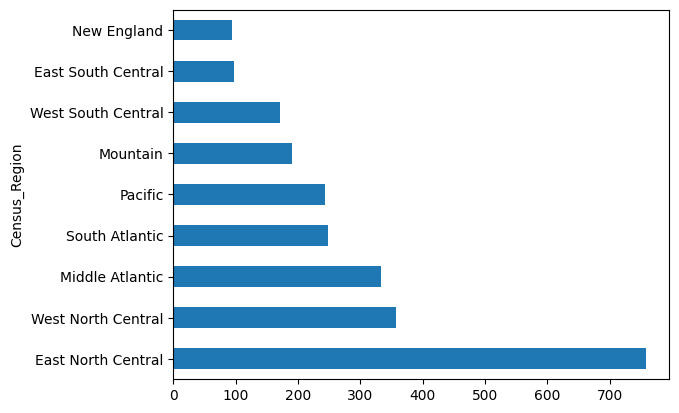

In [15]:
# Visualize the target distribution with a bar plot
# hint: use barh
y.value_counts().plot(kind='barh')

Is the target balanced (roughly the same number of examples per class) or imbalanced?

## Question 3: What are the features that can be used to predict the target?

Let's look at the column names and their data types.

In [ ]:
# List all column names
print(X.columns.tolist())


['RespondentID', 'What_would_you_call_the_part_of_the_country_you_live_in_now', 'How_much_do_you_personally_identify_as_a_Midwesterner', 'Do_you_consider_Illinois_state_as_part_of_the_Midwest', 'Do_you_consider_Indiana_state_as_part_of_the_Midwest', 'Do_you_consider_Iowa_state_as_part_of_the_Midwest', 'Do_you_consider_Kansas_state_as_part_of_the_Midwest', 'Do_you_consider_Michigan_state_as_part_of_the_Midwest', 'Do_you_consider_Minnesota_state_as_part_of_the_Midwest', 'Do_you_consider_Missouri_state_as_part_of_the_Midwest', 'Do_you_consider_Nebraska_state_as_part_of_the_Midwest', 'Do_you_consider_North_Dakota_state_as_part_of_the_Midwest', 'Do_you_consider_Ohio_state_as_part_of_the_Midwest', 'Do_you_consider_South_Dakota_state_as_part_of_the_Midwest', 'Do_you_consider_Wisconsin_state_as_part_of_the_Midwest', 'Do_you_consider_Arkansas_state_as_part_of_the_Midwest', 'Do_you_consider_Colorado_state_as_part_of_the_Midwest', 'Do_you_consider_Kentucky_state_as_part_of_the_Midwest', 'Do_you_c

In [ ]:
# Show data types for each column
print(X.dtypes)

RespondentID                                                   float64
What_would_you_call_the_part_of_the_country_you_live_in_now        str
How_much_do_you_personally_identify_as_a_Midwesterner              str
Do_you_consider_Illinois_state_as_part_of_the_Midwest              str
Do_you_consider_Indiana_state_as_part_of_the_Midwest               str
Do_you_consider_Iowa_state_as_part_of_the_Midwest                  str
Do_you_consider_Kansas_state_as_part_of_the_Midwest                str
Do_you_consider_Michigan_state_as_part_of_the_Midwest              str
Do_you_consider_Minnesota_state_as_part_of_the_Midwest             str
Do_you_consider_Missouri_state_as_part_of_the_Midwest              str
Do_you_consider_Nebraska_state_as_part_of_the_Midwest              str
Do_you_consider_North_Dakota_state_as_part_of_the_Midwest          str
Do_you_consider_Ohio_state_as_part_of_the_Midwest                  str
Do_you_consider_South_Dakota_state_as_part_of_the_Midwest          str
Do_you

How many features are numerical? How many are categorical (text)?

In [ ]:
Il y a une seule features numériques et 27 textuelles.

In [22]:
from skrub import TableReport
TableReport(X)

Processing column  28 / 28


,,,,,,,,,,,,,,,,,,,,,,,,,,,,


## Question 4: Are there any missing values in the dataset?

Missing values can cause problems for machine learning models.
Let's check if there are any.

In [23]:
# Check for NaN missing values
print(X.isnull().sum())

RespondentID                                                   0
What_would_you_call_the_part_of_the_country_you_live_in_now    0
How_much_do_you_personally_identify_as_a_Midwesterner          0
Do_you_consider_Illinois_state_as_part_of_the_Midwest          0
Do_you_consider_Indiana_state_as_part_of_the_Midwest           0
Do_you_consider_Iowa_state_as_part_of_the_Midwest              0
Do_you_consider_Kansas_state_as_part_of_the_Midwest            0
Do_you_consider_Michigan_state_as_part_of_the_Midwest          0
Do_you_consider_Minnesota_state_as_part_of_the_Midwest         0
Do_you_consider_Missouri_state_as_part_of_the_Midwest          0
Do_you_consider_Nebraska_state_as_part_of_the_Midwest          0
Do_you_consider_North_Dakota_state_as_part_of_the_Midwest      0
Do_you_consider_Ohio_state_as_part_of_the_Midwest              0
Do_you_consider_South_Dakota_state_as_part_of_the_Midwest      0
Do_you_consider_Wisconsin_state_as_part_of_the_Midwest         0
Do_you_consider_Arkansas_

Missing values can sometimes be encoded differently. Let's look at some columns more closely.

In [24]:
# Look at unique values for the Household_Income column
#X["Household_Income"].??
print(X["Household_Income"].unique())

<StringArray>
[  '$50,000 - $99,999',        '$0 - $24,999',   '$25,000 - $49,999',
           '$150,000+', '$100,000 - $149,999',                   '?']
Length: 6, dtype: str


In [25]:
# Look at unique values for the Education column
print(X["Education"].unique())

<StringArray>
[          'High school degree', 'Associate or bachelor degree',
              'Graduate degree',                 'Some college',
 'Less than high school degree',                            '?']
Length: 6, dtype: str


Do you see a special value that could represent missing data?

## Question 5: What is the most common answer to "How much do you personally identify as a Midwesterner"?

Let's explore this important feature.

In [26]:
# TODO: display the value counts for the column
# "How_much_do_you_personally_identify_as_a_Midwesterner"
print(X["How_much_do_you_personally_identify_as_a_Midwesterner"].value_counts())

How_much_do_you_personally_identify_as_a_Midwesterner
Not at all    965
A lot         697
Some          528
Not much      304
Name: count, dtype: int64


<Axes: xlabel='How_much_do_you_personally_identify_as_a_Midwesterner'>

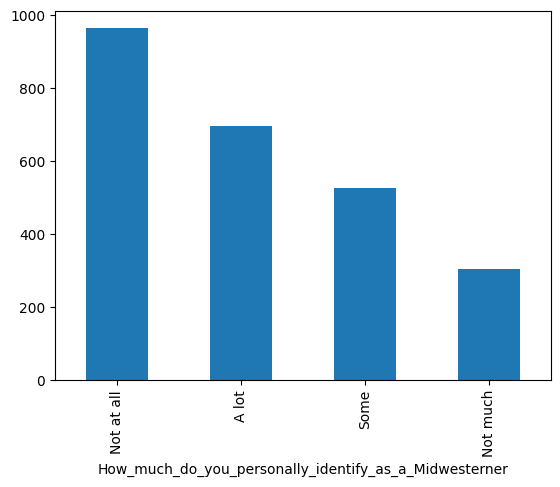

In [27]:
# TODO: make a bar plot of the results
X["How_much_do_you_personally_identify_as_a_Midwesterner"].value_counts().plot(kind='bar')

## Bonus: Explore another feature

Pick another column and explore its distribution.
For example: `Gender`, `Age`, or one of the
"Do you consider X state as part of the Midwest" columns.

In [ ]:
# TODO: explore a column of your choice